---
title: "Lecture 5: Joint and Marginal Distributions, Conditioning, Independence"
author: "Jamie Haddock"
format:
    revealjs:
        output-file: Lecture5_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
        html-math-method: katex
    html:
        code-fold: true
        embed-resources: true
        output-file: Lecture5
        code-links:
          - text: "Open in Colab"
            href: "https://colab.research.google.com/github/jamiehadd/Math-151-Probability/blob/main/05_joint-and-marginal-distributions-conditioning-independence.ipynb"
            icon: "laptop"
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        output-file: Lecture5
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: python3
colab:
  gh-user: "jamiehadd"
  gh-repo: "Math-151-Probability"
filters:
  - input/remove-pause.lua
  - colab
execute:
  echo: true
  eval: true
---

## Why look at two random variables together?

So far we've studied one random variable at a time. But often we care about how *two*
random variables move together — two dice rolled at once, or (in randomized Kaczmarz)
the row index sampled at one iteration versus the next. Knowing each RV's own PMF
separately says nothing about how they *relate*.

::: {.callout-note}
## Definition: Joint PMF
For discrete random variables $X,Y$ on the same probability space,
$$
p_{X,Y}(x,y) = P(X=x,\,Y=y).
$$
Like any PMF, it's nonnegative and sums to $1$ over all pairs $(x,y)$. It's strictly
more informative than $p_X$ and $p_Y$ separately — it tells us how $X$ and $Y$
*co-vary*.
:::

. . .

**Two-die-roll example:** Let $X$ = first die, $Y$ = second die -- all $36$ outcomes
$(x,y)\in\{1,\dots,6\}^2$ are equally likely, so
$$
p_{X,Y}(x,y) = \frac{1}{36}, \qquad x,y\in\{1,\dots,6\}.
$$

. . .

::: {.callout-warning}
## Joint distributions of arbitrarily many RVs!
We may consider joint PMFs of any number of RVs defined on the same probability space, $p_{\{X_i\}_{i=1}^k}(\{x_i\}_{i=1}^k) = P(X_1=x_1, \cdots, X_k=x_k)$.
:::

## Marginal PMF

::: {.callout-note}
## Definition: Marginal PMF
Given a joint PMF $p_{X,Y}$, the **marginal PMF** of $X$ is recovered by summing out
$y$:
$$
p_X(x) = P(X=x) = \sum_y p_{X,Y}(x,y),
$$
and symmetrically $p_Y(y) = \sum_x p_{X,Y}(x,y)$.
:::

. . .

**Two-die-roll example:** summing each row of the $36$-entry joint table over $y$
gives
$$
p_X(x) = \sum_{y=1}^6 \frac{1}{36} = \frac{6}{36} = \frac16, \qquad x=1,\dots,6,
$$
recovering the familiar single-die PMF.

## Expectation of a function of two RVs

::: {.callout-note}
## Theorem: LOTUS for two random variables
For random variables $X,Y$ and any function $g$,
$$
E[g(X,Y)] = \sum_{x,y} g(x,y)\, p_{X,Y}(x,y).
$$
:::

. . .

Taking $g(x,y) = ax+by+c$ recovers linearity of expectation that we saw previously:
$$
E[aX+bY+c] = \sum_{x,y}(ax+by+c)\,p_{X,Y}(x,y)
= a\sum_x x\,p_X(x) + b\sum_y y\,p_Y(y) + c = aE[X]+bE[Y]+c.
$$
(The middle step uses the marginal-PMF definition — summing $y$ out of
$ax\,p_{X,Y}(x,y)$ leaves $ax\,p_X(x)$, and likewise for the $y$ term.)

## Example: the hat-check problem

$n$ people check their hats at a party; the hats are returned to them in a uniformly
random order (a uniformly random permutation of the $n$ hats). Let $X$ = number of
people who get their own hat back. Find $E[X]$.

. . .

Write $X = \sum_{i=1}^n X_i$, where $X_i = \mathbf 1_{\{\text{person } i \text{ gets
their own hat back}\}}$. By symmetry every person is equally likely to receive any of
the $n$ hats, so $P(X_i=1) = \tfrac1n$ and $E[X_i]=\tfrac1n$.

::: {.callout-warning}
## The $X_i$ are *not* independent!
If the first $n-1$ people all get their own hat back, the last person is guaranteed
to as well — knowing some $X_i$'s tells you a lot about the others. But, just like the
expectation of the Binomial calculation we saw previously, **linearity doesn't care**:
:::

$$
E[X] = \sum_{i=1}^n E[X_i] = n\cdot\frac1n = 1.
$$

However many people are at the party, on average exactly **one** person gets their
own hat back!

## Conditioning

We've used conditional probability previously — let's now define *conditional
distributions* of random variables precisely.

::: {.callout-note}
## Definition: Conditional PMF given an event
For an event $A$ with $P(A)>0$,
$$
p_{X|A}(x) = P(X=x\mid A) = \frac{P(\{X=x\}\cap A)}{P(A)}.
$$
:::

**Revisiting our die-roll example:** let $X$ be a single fair die roll and
$A=\{X\text{ is even}\}=\{2,4,6\}$. Then
$$
p_{X|A}(x) = \begin{cases}\frac13 & x\in\{2,4,6\}\\ 0 & \text{otherwise,}\end{cases}.
$$

## Conditioning on another random variable

::: {.callout-note}
## Definition: Conditional PMF given $Y=y$
For $p_Y(y) > 0$,
$$
p_{X|Y}(x\mid y) = P(X=x\mid Y=y) = \frac{p_{X,Y}(x,y)}{p_Y(y)}.
$$
:::

. . .

This is exactly the previous definition applied to the event $A=\{Y=y\}$.

## Grid view of the joint PMF, slice view of the conditional PMF

ADD PICTURE

## Recovering the marginal from conditional PMFs

::: {.callout-note}
## Theorem (total probability, for random variables)
$$
p_X(x) = \sum_y p_Y(y)\, p_{X|Y}(x\mid y).
$$
:::

. . .

This is just $p_X(x)=\sum_y p_{X,Y}(x,y)$ (the marginal definition) with
$p_{X,Y}(x,y)=p_Y(y)\,p_{X|Y}(x|y)$ substituted in.

. . .

**Dice example, continued:** weighting each of the $6$ conditional slices
$p_{X|Y}(\cdot\mid y)$ by $p_Y(y)=\tfrac16$ and summing should reconstruct the
familiar triangular sum-of-two-dice PMF from L4's craps example — let's check.

## Conditional expectation

::: {.callout-note}
## Definitions: conditional expectation
$$
E[X\mid A] = \sum_x x\, p_{X|A}(x), \qquad\qquad
E[X\mid Y=y] = \sum_x x\, p_{X|Y}(x\mid y).
$$
:::

Same idea as ordinary expectation — just averaging $x$ against the *conditional* PMF
instead of the unconditional one.

## Law of total expectation -- three forms

- **Partition form:** if $A_1,\dots,A_n$ partition the sample space,
  $\displaystyle E[X] = \sum_{i=1}^n P(A_i)\,E[X\mid A_i]$.
- **Conditioned partition form:** for any event $B$,
  $\displaystyle E[X\mid B] = \sum_{i=1}^n P(A_i\mid B)\,E[X\mid A_i\cap B]$.
- **Random-variable form:**
  $\displaystyle E[X] = \sum_y p_Y(y)\,E[X\mid Y=y]$.

. . .

All three say the same thing: split the world into (disjoint) pieces, compute the (conditional)
expectation on each piece, and average the pieces back together weighted by how
likely each one is.

. . .

This is a useful computational trick: whenever a direct
computation of $E[X]$ looks hard, look for a natural way to split on "what happened
first," compute the easy conditional pieces, and average.

## Example: mean and variance of the Geometric, the slick way

Let $X\sim\text{Geometric}(p)$ (number of trials until the first success). Condition
on the first trial: $A=\{\text{trial 1 succeeds}\}$, $P(A)=p$.

- If $A$ occurs, $X=1$, so $E[X\mid A]=1$.
- If $A^c$ occurs, that trial was wasted and — by memorylessness — we're back to
  square one: $X = 1+X'$ for a fresh Geometric($p$) copy $X'$, so
  $E[X\mid A^c] = 1+E[X]$.

. . .

By the law of total expectation,
$$
E[X] = P(A)E[X\mid A] + P(A^c)E[X\mid A^c] = p\cdot 1 + (1-p)\big(1+E[X]\big)
= 1 + (1-p)E[X],
$$
so $p\,E[X]=1$, giving $E[X] = \tfrac1p$ — which matches our previous calculation.

---

The same trick on $X^2$: $X^2\mid A^c = (1+X')^2 = 1+2X'+X'^2$, so
$$
E[X^2] = p + (1-p)\big(1+2E[X]+E[X^2]\big) = 1+2(1-p)E[X] + (1-p)E[X^2],
$$
which solves to $E[X^2] = \dfrac{2-p}{p^2}$, and therefore
$\mathrm{Var}(X) = E[X^2]-(E[X])^2 = \dfrac{1-p}{p^2}$ — exactly what L4's in-class
activity found by a very different route.

## Recursing the randomized Kaczmarz bound

Recall L4's one-step bound, valid conditional on the *current* iterate $x_k$:
$$
E\big[\|x_{k+1}-x^\star\|^2 \mid x_k\big] \le (1-c)\,\|x_k-x^\star\|^2,
\qquad c = \frac{\sigma_{\min}(A)^2}{\|A\|_F^2}.
$$
That's only a statement about *one* step, conditional on where we happen to be. To
turn it into an unconditional guarantee after $k$ steps, apply the law of total
expectation repeatedly:
$$
E\big[\|x_2-x^\star\|^2\big] = E\Big[E\big[\|x_2-x^\star\|^2 \mid x_1\big]\Big]
\le E\big[(1-c)\|x_1-x^\star\|^2\big] = (1-c)\,E\big[\|x_1-x^\star\|^2\big]
\le (1-c)^2\|x_0-x^\star\|^2.
$$

. . .

Repeating this argument (tower property, one step at a time) gives, for every $k$,
$$
E\big[\|x_k-x^\star\|^2\big] \le (1-c)^k \|x_0-x^\star\|^2,
$$
— exactly the compounded bound we *plotted* in L4 but never quite justified. Now we
know why "applying the one-step bound repeatedly" is legitimate: it's the law of
total expectation, used $k$ times.

In [10]:
rng = np.random.default_rng(151)
m, n = 20, 8
A = rng.standard_normal((m, n))
x_star = rng.standard_normal(n)
b = A @ x_star
row_norm_sq = (A ** 2).sum(axis=1)
p_row_norm = row_norm_sq / row_norm_sq.sum()
sigma_min = np.linalg.svd(A, compute_uv=False)[-1]
frob_sq = row_norm_sq.sum()
c = sigma_min**2 / frob_sq

num_steps = 60
num_runs = 2000
checkpoints = [0, 10, 20, 30, 40, 50, 60]
errors_sq = np.zeros((num_runs, num_steps + 1))

for r in range(num_runs):
    x = np.zeros(n)
    errors_sq[r, 0] = np.linalg.norm(x - x_star) ** 2
    idx_sequence = rng.choice(m, size=num_steps, p=p_row_norm)
    for t, i in enumerate(idx_sequence, start=1):
        a_i, b_i = A[i], b[i]
        x = x + (b_i - a_i @ x) / row_norm_sq[i] * a_i
        errors_sq[r, t] = np.linalg.norm(x - x_star) ** 2

mean_error_sq = errors_sq.mean(axis=0)
initial_error_sq = errors_sq[:, 0].mean()

print(f"{'k':>4} {'empirical E[||x_k-x*||^2]':>28} {'bound (1-c)^k ||x_0-x*||^2':>28}")
for k in checkpoints:
    bound = initial_error_sq * (1 - c) ** k
    print(f"{k:>4} {mean_error_sq[k]:>28.5f} {bound:>28.5f}")

   k    empirical E[||x_k-x*||^2]   bound (1-c)^k ||x_0-x*||^2
   0                     14.24286                     14.24286
  10                      5.34193                      9.61687
  20                      2.26812                      6.49338
  30                      1.00931                      4.38437
  40                      0.45129                      2.96036
  50                      0.20803                      1.99885
  60                      0.09983                      1.34964


## Independence

We've been hinting at independence all lecture — with-replacement RK sampling, the
i.i.d. sums behind linearity examples. Time to define it for random variables,
building on L2's definition for events.

::: {.callout-note}
## Definition: independence of a random variable from an event
$X$ is independent of event $A$ if
$$
p_{X\mid A}(x) = p_X(x)\quad\text{for every } x,
$$
i.e. learning that $A$ occurred tells you nothing new about $X$. Equivalently,
$P(X=x, A) = P(X=x)P(A)$ for every $x$ — the L2 definition of independent events,
applied to $\{X=x\}$ and $A$.
:::

## Independence of two random variables

::: {.callout-note}
## Definition: independence of random variables
$X$ and $Y$ are **independent** if
$$
p_{X,Y}(x,y) = p_X(x)\,p_Y(y) \quad \text{for all } x,y,
$$
equivalently $p_{X|Y}(x\mid y) = p_X(x)$ whenever $p_Y(y)>0$ — conditioning on $Y$
never changes $X$'s distribution.
:::

**Revisiting our RK example:** Recall randomized Kaczmarz samples a row index $I_k\in\{1,\dots,m\}$ at every
iteration from a fixed PMF $p_I$ (e.g. the row-norm PMF from L3–L4), **with
replacement** — each iteration's draw doesn't remove that row from future
consideration.

Because the draws are made independently at each iteration, the joint PMF of the indices at two iterations
factors:
$$
p_{I_1,I_2}(i,j) = p_I(i)\,p_I(j).
$$

. . .

Contrast this with L2's *without-replacement* row-sampling comparison — there,
removing a row after sampling it means the joint PMF of two draws does **not**
factor this way (the second draw's distribution depends on what the first draw was).

## Conditional Independence

::: {.callout-note}
## Definition: conditional independence
$X$ and $Y$ are **conditionally independent given event $C$** if
$$
p_{X,Y\mid C}(x,y) = p_{X\mid C}(x)\, p_{Y\mid C}(y) \quad \text{for all } x,y.
$$
:::

::: {.callout-warning}
## Recall from L2: these are genuinely different notions!
A pair of random variables can be independent but not conditionally independent
given some $C$, or conditionally independent given $C$ without being (unconditionally)
independent — exactly like the two-coin examples from L2's independence discussion.
:::

## A key fact: $E[XY]=E[X]E[Y]$ for independent $X,Y$

We used this fact in L4 to prove Hutchinson's trace estimator is unbiased — as a
preview, without a real proof. Now we have the tools.

::: {.callout-note}
## Fact
If $X,Y$ are independent, $E[XY]=E[X]E[Y]$.
:::

**Proof:** apply two-variable LOTUS with $g(x,y)=xy$, then use independence:
$$
E[XY] = \sum_{x,y} xy\,p_{X,Y}(x,y) = \sum_{x,y}xy\,p_X(x)p_Y(y)
= \Big(\sum_x x\,p_X(x)\Big)\Big(\sum_y y\,p_Y(y)\Big) = E[X]E[Y]. \qquad\blacksquare
$$

::: {.callout-warning}
## Independence is essential here
Contrast with linearity of expectation, which needed nothing. In general
$E[XY]\ne E[X]E[Y]$: e.g. take $Y=X$, so $E[XY]=E[X^2]\ne (E[X])^2=E[X]E[Y]$ unless
$\mathrm{Var}(X)=0$.
:::

## Variance of a sum, finally proved

::: {.callout-note}
## Theorem (stated in L4): for independent $X,Y$,
$$
\mathrm{Var}(X+Y) = \mathrm{Var}(X)+\mathrm{Var}(Y).
$$
:::

**Proof:** let $\mu_X=E[X],\mu_Y=E[Y]$. Expanding and using linearity twice,
$$
\mathrm{Var}(X+Y) = E\big[((X-\mu_X)+(Y-\mu_Y))^2\big]
= \mathrm{Var}(X)+\mathrm{Var}(Y)+2\,E\big[(X-\mu_X)(Y-\mu_Y)\big].
$$
Expanding the cross term and applying the fact above,
$$
E\big[(X-\mu_X)(Y-\mu_Y)\big] = E[XY]-\mu_X\mu_Y = E[X]E[Y]-E[X]E[Y] = 0,
$$
so $\mathrm{Var}(X+Y)=\mathrm{Var}(X)+\mathrm{Var}(Y)$.

::: {.callout-warning}
## Where the cross term goes
That cross term, $E[(X-\mu_X)(Y-\mu_Y)]$, is called the **covariance** of $X,Y$. It
vanishes exactly because of independence; in general
$\mathrm{Var}(X+Y)=\mathrm{Var}(X)+\mathrm{Var}(Y)+2\,\mathrm{Cov}(X,Y)$.
:::

## Example: mean and variance of the sample mean

Let $X_1,\dots,X_n$ be i.i.d.\ with mean $\mu$ and variance $\sigma^2$, and let
$\bar X_n = \frac1n\sum_{i=1}^n X_i$.

$$
E[\bar X_n] = \frac1n\sum_{i=1}^n E[X_i] = \mu
\qquad\text{(linearity — independence not even needed).}
$$

. . .

$$
\mathrm{Var}(\bar X_n) = \frac1{n^2}\,\mathrm{Var}\Big(\sum_{i=1}^n X_i\Big)
= \frac1{n^2}\sum_{i=1}^n \mathrm{Var}(X_i) = \frac{\sigma^2}{n}
\qquad\text{(independence used here!)}
$$

The sample mean is unbiased, and its spread shrinks like $1/n$ — the mathematical
reason averaging more samples reduces noise, and the seed of the Law of Large Numbers
(coming later this course).

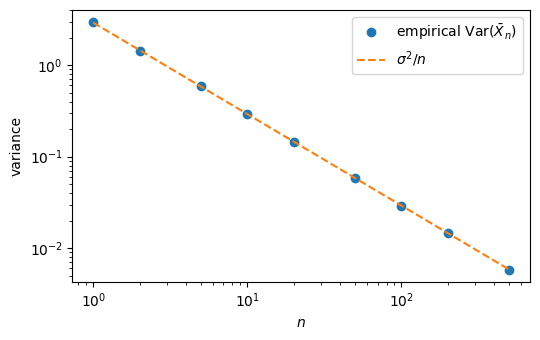

In [13]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(151)
n_values = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500])
repetitions = 20_000
sigma_sq = np.var(np.arange(1, 7))  # variance of a single fair die roll

empirical_var = []
for n in n_values:
    sample_means = rng.integers(1, 7, size=(repetitions, n)).mean(axis=1)
    empirical_var.append(sample_means.var())
empirical_var = np.array(empirical_var)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.loglog(n_values, empirical_var, 'o', label=r'empirical $\mathrm{Var}(\bar X_n)$')
ax.loglog(n_values, sigma_sq / n_values, '--', label=r'$\sigma^2/n$')
ax.set_xlabel('$n$')
ax.set_ylabel('variance')
ax.legend()
plt.tight_layout()
plt.show()

## Example: unbiasedness of randomized trace estimation, properly justified

Recall Hutchinson's estimator from L4: for $A\in\mathbb R^{n\times n}$, draw
$z\in\{-1,+1\}^n$ with i.i.d.\ Rademacher entries and set
$\tau = z^\top A z = \sum_{i,j} z_iz_j A_{ij}$. We checked $E[\tau]=\mathrm{tr}(A)$
numerically in L4; here's the real proof.

By linearity, $E[\tau] = \sum_{i,j}A_{ij}\,E[z_iz_j]$. Split into diagonal and
off-diagonal terms:

- **Diagonal ($i=j$):** $z_i^2=1$ always, so $E[z_i^2]=1$.
- **Off-diagonal ($i\ne j$):** $z_i,z_j$ independent, so by today's fact,
  $E[z_iz_j]=E[z_i]E[z_j] = 0\cdot 0=0$ (Rademacher has mean $0$).

. . .

$$
E[\tau] = \sum_i A_{ii}\cdot 1 + \sum_{i\ne j} A_{ij}\cdot 0 = \sum_i A_{ii}
= \mathrm{tr}(A).
$$

Unbiased — and now resting on a real proof rather than an aside. (Its *variance*,
and how many samples of $\tau$ you'd actually want to average, is still deferred to
L10.)

In [14]:
rng = np.random.default_rng(151)
d = 50
A = rng.standard_normal((d, d)) + 5 * np.eye(d)   # shift so tr(A) is clearly nonzero
true_trace = np.trace(A)

num_samples = 20_000
Z = rng.choice([-1.0, 1.0], size=(num_samples, d))
taus = np.einsum('si,ij,sj->s', Z, A, Z)

print(f"true trace(A)                          = {true_trace:.4f}")
print(f"mean of tau over {num_samples} samples = {taus.mean():.4f}")

# numerically check the pairwise-independence claim
print(f"\nE[z_1^2]   ~= {np.mean(Z[:, 0] * Z[:, 0]):.4f}   (theory: 1)")
print(f"E[z_1 z_2] ~= {np.mean(Z[:, 0] * Z[:, 1]):.4f}   (theory: 0)")

true trace(A)                          = 250.0783
mean of tau over 20000 samples = 249.9342

E[z_1^2]   ~= 1.0000   (theory: 1)
E[z_1 z_2] ~= -0.0027   (theory: 0)
